## Run INSPIRE on the human breast cancer Xenium sections

In this tutorial, we show INSPIRE’s application to analysis of human breast cancer sections profiled by Xenium, revealing microenvironment heterogeneity across tumor subtypes.

The human breast cancer Xenium sections are publicly available at [https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast](https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast).

### Import packages

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import umap
import os
import scipy.sparse
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

import INSPIRE

import warnings
warnings.filterwarnings("ignore")

### Data preprocessing

Each Xenium section contains a large number of cells. For efficiency, we preprocessed each section respectively.

In [2]:
# ## load data 1
# data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/data/Xenium_BC/Sample1_replicate1"
# adata = sc.read_10x_h5(data_dir + "/cell_feature_matrix.h5")
# coor_df = pd.read_csv(data_dir + "/cells.csv.gz")
# adata.obsm["spatial"] = coor_df[["x_centroid", "y_centroid"]].to_numpy()
# adata.obsm["spatial"][:,0] = - adata.obsm["spatial"][:,0]
# adata.obsm["spatial"][:,1] = - adata.obsm["spatial"][:,1]
# adata.obsm["spatial"] = adata.obsm["spatial"].astype(np.float32)
# adata.var_names_make_unique()
# adata.obs_names_make_unique()
# adata_1 = adata.copy()
# adata_1.obs.index = adata_1.obs.index + "-0"


# ## load data 2
# data_dir = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/data/Xenium_BC/Sample1_replicate2"
# adata = sc.read_10x_h5(data_dir + "/cell_feature_matrix.h5")
# coor_df = pd.read_csv(data_dir + "/cells.csv.gz")
# adata.obsm["spatial"] = coor_df[["x_centroid", "y_centroid"]].to_numpy()
# adata.obsm["spatial"][:,0] = - adata.obsm["spatial"][:,0]
# adata.obsm["spatial"][:,1] = - adata.obsm["spatial"][:,1]
# adata.obsm["spatial"] = adata.obsm["spatial"].astype(np.float32)
# adata.var_names_make_unique()
# adata.obs_names_make_unique()
# adata_2 = adata.copy()
# adata_2.obs.index = adata_2.obs.index + "-1"

# shared_genes = adata_1.var.index & adata_2.var.index
# adata_1 = adata_1[:, shared_genes].copy()
# adata_2 = adata_2[:, shared_genes].copy()
# del adata

# ## preprocess data 1
# INSPIRE.utils.calculate_node_features_LGCN(adata=adata_1,
#                                            slice_name="BC_sample1_rep1_qc6_radcutoff20",
#                                            preprocessed_data_path="/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/calculate_node_features/Xenium_BC",
#                                            min_genes_qc=6,
#                                            min_cells_qc=6,
#                                            rad_cutoff=20
#                                           )

# ## preprocess data 2
# INSPIRE.utils.calculate_node_features_LGCN(adata=adata_2,
#                                            slice_name="BC_sample1_rep2_qc6_radcutoff20",
#                                            preprocessed_data_path="/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/calculate_node_features/Xenium_BC",
#                                            min_genes_qc=6,
#                                            min_cells_qc=6,
#                                            rad_cutoff=20
#                                           )

The data after preprocessing are saved into preprocessed_data_path.

### Load preprocessed data

Finding highly variable genes...
Load data BC_sample1_rep1_qc6_radcutoff20
Load data BC_sample1_rep2_qc6_radcutoff20
Find 313 shared highly variable genes among datasets.
Store counts and library sizes for Poisson modeling...
Normalize data...
Load data BC_sample1_rep1_qc6_radcutoff20
Load data BC_sample1_rep2_qc6_radcutoff20
Load and prepare node features for LGCN...
Load node features BC_sample1_rep1_qc6_radcutoff20
Node features for slice 0 : (164596, 626)
Load node features BC_sample1_rep2_qc6_radcutoff20
Node features for slice 1 : (118467, 626)
Prepare an adata containing full spot locations and slice labels for better visualization...


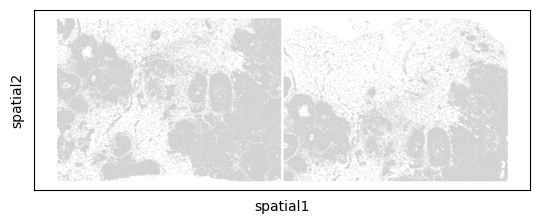

In [3]:
slice_name_list = ["BC_sample1_rep1_qc6_radcutoff20", "BC_sample1_rep2_qc6_radcutoff20"]
preprocessed_data_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/calculate_node_features/Xenium_BC"

adata_st_list, adata_full = INSPIRE.utils.prepare_inputs_LGCN(slice_name_list=slice_name_list,
                                                              preprocessed_data_path=preprocessed_data_path,
                                                              num_hvgs=500,
                                                              spot_size=20.,
                                                              min_concat_dist=100)

### Run INSPIRE model

In [4]:
model = INSPIRE.model.Model_LGCN(adata_st_list=adata_st_list,
                                 n_spatial_factors=50,
                                 n_training_steps=20000,
                                 batch_size=2048
                                )

In [5]:
model.train(adata_st_list)

  0%|          | 6/20000 [00:02<1:35:14,  3.50it/s] 

Step: 0, d_loss: 1.4172, Loss: 1567.6923, recon_loss: 499.5919, fe_loss: 79.1669, geom_loss: 74.5035, beta_loss: 986.3552, gan_loss: 1.0883


  3%|▎         | 507/20000 [00:12<06:32, 49.63it/s]

Step: 500, d_loss: 1.3132, Loss: 1309.3512, recon_loss: 339.4700, fe_loss: 45.5029, geom_loss: 88.7015, beta_loss: 921.8173, gan_loss: 0.7870


  5%|▌         | 1007/20000 [00:22<06:37, 47.72it/s]

...

 95%|█████████▌| 19007/20000 [06:29<00:20, 48.60it/s]

Step: 19000, d_loss: 0.7876, Loss: 894.5960, recon_loss: -71.3222, fe_loss: 41.5344, geom_loss: 49.3036, beta_loss: 921.6761, gan_loss: 1.7215


 98%|█████████▊| 19507/20000 [06:39<00:10, 48.87it/s]

Step: 19500, d_loss: 0.7333, Loss: 906.0635, recon_loss: -60.4748, fe_loss: 41.8529, geom_loss: 50.6278, beta_loss: 921.8535, gan_loss: 1.8193


100%|██████████| 20000/20000 [06:49<00:00, 48.85it/s]


### Access cell representations, proportions of spatial factors in cells, and gene loading matrix

We evaluate the cells representations and proportions of spatial factors in cells with minibatches.

In [6]:
adata_full, basis_df = model.eval_minibatch(adata_st_list,
                                            adata_full,
                                            batch_size=10000
                                           )

Evaluate Z and beta using minibatch...
Evaluation for slice 0
Evaluation for slice 1


We calculate 2D UMAP coordinates of cells across sections based on INSPIRE’s inferred cell representations.

In [7]:
reducer = umap.UMAP(n_neighbors=30,
                    n_components=2,
                    metric="correlation",
                    n_epochs=None,
                    learning_rate=1.0,
                    min_dist=0.3,
                    spread=1.0,
                    set_op_mix_ratio=1.0,
                    local_connectivity=1,
                    repulsion_strength=1,
                    negative_sample_rate=5,
                    a=None,
                    b=None,
                    random_state=1234,
                    metric_kwds=None,
                    angular_rp_forest=False,
                    verbose=True)
embedding = reducer.fit_transform(adata_full.obsm['latent'])
adata_full.obsm["X_umap"] = embedding

UMAP(angular_rp_forest=True, local_connectivity=1, metric='correlation', min_dist=0.3, n_neighbors=30, random_state=1234, repulsion_strength=1, verbose=True)
Thu May 29 10:20:57 2025 Construct fuzzy simplicial set
Thu May 29 10:20:57 2025 Finding Nearest Neighbors
Thu May 29 10:20:57 2025 Building RP forest with 32 trees
Thu May 29 10:21:01 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	Stopping threshold met -- exiting after 4 iterations
Thu May 29 10:21:28 2025 Finished Nearest Neighbor Search
Thu May 29 10:21:32 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu May 29 10:27:50 2025 Finished embedding


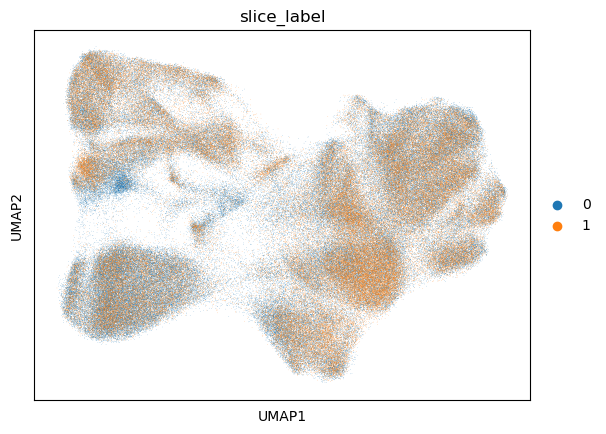

In [8]:
adata_full.obs["slice_label"] = adata_full.obs["slice_label"].values.astype(str)
sc.pl.umap(adata_full, color=["slice_label"])

### Save results

In [9]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/human_breast_cancer_xenium"
adata_full.write(res_path + "/adata_inspire.h5ad")
basis_df.to_csv(res_path + "/basis_df_inspire.csv")